## ***📰 News Article Category Classification Using Naive Bayes***

In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv(r"C:\Users\Yuvraj Bhavsar\OneDrive\Desktop\Class\AG News Classification Dataset\train.csv")
test = pd.read_csv(r"C:\Users\Yuvraj Bhavsar\OneDrive\Desktop\Class\AG News Classification Dataset\test.csv")

In [3]:
train.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [4]:
test.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [5]:
train.shape

(120000, 3)

In [6]:
train["title_len"] = train["Title"].apply(len)
train["desc_len"]  = train["Description"].apply(len)

train[["title_len", "desc_len"]].describe()

,title_len,desc_len
count,120000.000000,120000.000000
mean,42.071508,193.388517
std,13.569405,64.472066
min,6.000000,6.000000
25%,33.000000,155.000000
50%,41.000000,188.000000
75%,49.000000,219.000000
max,115.000000,985.000000


In [7]:
for i in range(1,5):
    print(f"\nCategory {i} sample:")
    print(train[train["Class Index"] == i].iloc[0]["Title"])


Category 1 sample:
Venezuelans Vote Early in Referendum on Chavez Rule (Reuters)

Category 2 sample:
Phelps, Thorpe Advance in 200 Freestyle (AP)

Category 3 sample:
Wall St. Bears Claw Back Into the Black (Reuters)

Category 4 sample:
'Madden,' 'ESPN' Football Score in Different Ways (Reuters)


In [8]:
train["text"] = train["Title"] + " " + train["Description"]
test["text"]  = test["Title"] + " " + test["Description"]

In [9]:
test["text"] = test["text"].str.lower()
train["text"] = train["text"].str.lower()

In [10]:
train["text_length"] = train["text"].apply(lambda x: len(x.split()))

In [11]:
train.head()

,Class Index,Title,Description,title_len,desc_len,text,text_length
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",49,94,wall st. bears claw back into the black (reute...,21
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,51,214,carlyle looks toward commercial aerospace (reu...,36
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,47,184,oil and economy cloud stocks' outlook (reuters...,36
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,60,195,iraq halts oil exports from main southern pipe...,36
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",73,160,"oil prices soar to all-time record, posing new...",37


In [12]:
import re

def clean_text(text):
    text = re.sub(r"[^a-z\s]", "", text)
    return text

train["text"] = train["text"].apply(clean_text)
test["text"] = test["text"].apply(clean_text)

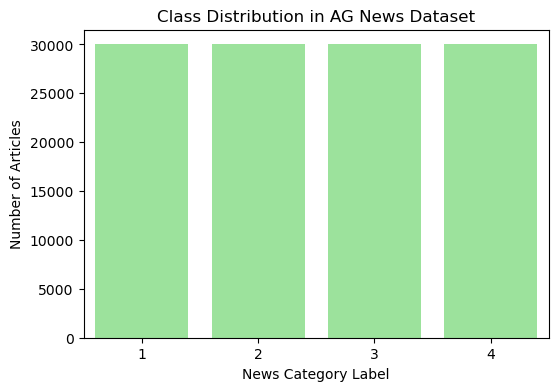

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=train["Class Index"],color="lightgreen")
plt.title("Class Distribution in AG News Dataset")
plt.xlabel("News Category Label")
plt.ylabel("Number of Articles")
plt.show()

### **Feature Extraction Using TF-IDF**

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1,2)   # unigrams + bigrams
)

X_train = vectorizer.fit_transform(train["text"])
y_train = train["Class Index"]
X_test = vectorizer.transform(test["text"])
y_test = test["Class Index"]

In [17]:
print(X_train.shape)
print(X_test.shape)

(120000, 50000)
(7600, 50000)


In [ ]:
Naive bayes

In [18]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(alpha=1.0)  # Laplace smoothing

In [19]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [20]:
y_pred = nb_model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9071052631578947


In [22]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(nb_model.classes_):
    top10 = np.argsort(nb_model.feature_log_prob_[i])[-10:]
    print(f"\nTop words for class {class_label}:")
    print([feature_names[j] for j in top10])


Top words for class 1:
['people', 'iraqi', 'killed', 'minister', 'afp', 'president', 'reuters', 'said', 'ap', 'iraq']

Top words for class 2:
['new', 'victory', 'league', 'cup', 'night', 'season', 'win', 'team', 'game', 'ap']

Top words for class 3:
['sales', 'stocks', 'profit', 'percent', 'company', 'prices', 'new', 'said', 'reuters', 'oil']

Top words for class 4:
['search', 'computer', 'music', 'reuters', 'space', 'ap', 'internet', 'software', 'new', 'microsoft']


| Class Label | News Category   |
| ----------- | --------------- |
| **1**       | 🌍 **World**    |
| **2**       | 🏅 **Sports**   |
| **3**       | 💼 **Business** |
| **4**       | 💻 **Sci/Tech** |
